In [35]:
import sys, numpy, pandas, sklearn
print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]
NumPy: 2.0.2
pandas: 2.3.3
scikit-learn: 1.6.1


YOUR_ID=3194

In [36]:
import pandas as pd

raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=3194)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe(include="all").T)

(1153, 11)
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           57
building_type         0
ceiling_height_m    137
price_kzt             0
dtype: int64
                   count unique         top freq        mean         std  min  \
listing_id          1153   1080   ALM-11147    3         NaN         NaN  NaN   
listed_date         1153    246  2026-04-18   11         NaN         NaN  NaN   
district            1153     48       Medeu  145         NaN         NaN  NaN   
rooms               1153      6           2  432         NaN      

In [37]:
print(df["rooms"].sample(10, random_state=1).tolist())
print(df["area_m2"].sample(10, random_state=1).tolist())
print(df["price_kzt"].sample(10, random_state=1).tolist())

['2', '2', '3', '3', '3', '2', '2', '3', '2', '3']
['46.7', '58.2', '74.9', '61.9', '74.6 m²', '59.5', '53.1', '97.4', '44.7', '69.5']
['21780000', '55940000', '38520000', '70060000', '80150000', '43540000', '31650000', '77850000', '49470000', '37700000']


In [38]:
print(df.loc[df["rooms"].str.contains(r"[^0-9]", na=False), "rooms"].unique())
print(df.loc[df["area_m2"].str.contains(r"[^0-9.]", na=False), "area_m2"].unique())
print(df.loc[df["price_kzt"].str.contains(r"[^0-9]", na=False), "price_kzt"].unique())

['studio']
['54.6 m²' '40,8' '62,2' '61.1 m²' '40.8 m²' '43.4 m²' '38.2 m²' '33,7'
 '61.3 m²' '60,4' '80.0 m²' '93.8 m²' '84.4 m²' '122,5' '75.7 m²' '90,7'
 '45,7' '44.2 m²' '63,0' '36,3' '56.8 m²' '146,5' '66,5' '61,1' '66.3 m²'
 '50.0 m²' '120,1' '37,3' '36.4 m²' '39.6 m²' '35.4 m²' '35,2' '37.9 m²'
 '39,0' '68,1' '43.7 m²' '53,9' '68,9' '122,3' '61,9' '78,4' '74.6 m²'
 '62,0' '65.4 m²' '77,4' '82,7' '49,8' '99,6' '86.9 m²' '34,2' '54.5 m²'
 '43,6' '56,3' '78.6 m²' '95,8' '58,6' '79,0' '102.6 m²' '63.4 m²'
 '55.5 m²' '107,4' '44.8 m²' '56,6' '69,2' '49.9 m²' '45,3' '58.9 m²'
 '34.3 m²' '54.3 m²' '75,3' '109,0' '150,8' '112.0 m²' '37,8' '48.5 m²'
 '42.2 m²' '38,9' '35,1' '46.8 m²' '81.8 m²' '58,2' '84.7 m²' '102.1 m²'
 '153.1 m²' '65.0 m²' '42.6 m²' '47.3 m²' '114.9 m²']
['29 060 000 ₸' '52,760,000' '31,620,000' '70,860,000' '32 620 000 ₸'
 '19 960 000 ₸' '44,710,000' '33 820 000 ₸' '39 780 000 ₸' '46 720 000 ₸'
 '103 440 000 ₸' '49,760,000' '41,950,000' '32,730,000' '60,900,000'
 '55

## Step 2 — Question 1: Types

rooms, area_m2 and price_kzt are object but should be numbers.

- rooms: has the value "studio" instead of a number. I'll count it as 1 room.
- area_m2: some values look like "54.6 m²" (point as decimal, with unit), others like "40,8" (comma as decimal, no unit). Same meaning, different format.
- price_kzt: some values look like "29 060 000 ₸" (spaces + currency sign), others like "52,760,000" (commas). Here the comma means thousands, not decimal — different rule than in area_m2.

Other object columns are fine as text: listing_id, listed_date, district, building_type.

In [39]:
print(df.duplicated().sum())
print(df.drop_duplicates()["listing_id"].duplicated().sum())

32
41


In [40]:
clean = df.drop_duplicates()
dup_ids = clean.loc[clean["listing_id"].duplicated(keep=False), "listing_id"].unique()
print(clean[clean["listing_id"] == dup_ids[0]])
print()
print(clean[clean["listing_id"] == dup_ids[1]])

    listing_id listed_date district rooms area_m2  floor  total_floors  \
7    ALM-10003  2026-05-29   Auezov     2    48.6      2             5   
969  ALM-10003  2026-05-04   Auezov     2    48.6      2             5   

     year_built building_type  ceiling_height_m price_kzt  
7        1978.0         panel              2.55  26120000  
969      1978.0         panel              2.55  28320000  

    listing_id listed_date district rooms area_m2  floor  total_floors  \
11   ALM-10938  2026-08-10    Medeu     5   133.0      1             9   
519  ALM-10938  2026-08-21    Medeu     5   133.0      1             9   

     year_built building_type  ceiling_height_m  price_kzt  
11       2013.0      monolith              2.93  177470000  
519      2013.0      monolith              2.93  167850000  


## Step 2 — Question 2: Grain

Exact duplicates (df.duplicated().sum()): 32
Repost pairs (same listing_id after dropping exact duplicates): 41

Looking at two repost pairs, only listed_date and price_kzt differ between rows sharing a listing_id — every physical attribute (district, rooms, area_m2, floor, total_floors, year_built, building_type, ceiling_height_m) is identical. In both examples I checked, the price dropped on the later posting, suggesting the seller lowered the price over time. So when resolving reposts I'll keep the most recent posting (latest listed_date), since it reflects the seller's latest asking price.

Grain: one row in the cleaned table represents one unique apartment listing — after removing exact duplicates and keeping only the latest posting per listing_id.

## Step 2 — Question 3: Validation spec

| Column | Expected type | Valid range |
|---|---|---|
| listing_id | string | unique per listing |
| listed_date | date | 2020-01-01 to today |
| district | category | one of 8 canonical Almaty districts |
| rooms | int | 1 to 8 |
| area_m2 | float | 10 to 300 |
| floor | int | 1 to total_floors |
| total_floors | int | 1 to 30 |
| year_built | int | 1950 to 2026 |
| building_type | category | panel / brick / monolith |
| ceiling_height_m | float | 2.2 to 4.5 |
| price_kzt | float | > 0 |

In [41]:
print("rows before:", len(df))

df = df.drop_duplicates()
print("rows after exact dedup:", len(df))

df["listed_date"] = pd.to_datetime(df["listed_date"])
df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last").reset_index(drop=True)
print("rows after repost resolve:", len(df))

rows before: 1153
rows after exact dedup: 1121
rows after repost resolve: 1080


In [42]:
print(df["district"].value_counts())

district
Medeu            135
Bostandyk        127
Turksib          121
Zhetysu          116
Almaly           111
Auezov           110
Alatau           102
Nauryzbay        102
turksib            8
medeu              8
auezov             8
AUEZOV             7
Auezovskiy         7
bostandyk          7
Наурызбайский      7
Nauryzbayskiy      6
 Auezov            6
Alatauskiy         5
 Turksib           5
Bostandykskiy      5
 Zhetysu           5
Медеуский          4
almaly             4
TURKSIB            4
NAURYZBAY          4
nauryzbay          4
MEDEU              4
 Almaly            4
 Medeu             3
 Bostandyk         3
BOSTANDYK          3
 Alatau            3
Бостандыкский      3
Zhetysuskiy        3
ALMALY             3
Almalinskiy        3
Турксибский        2
Turksibskiy        2
ZHETYSU            2
 Nauryzbay         2
ALATAU             2
zhetysu            2
Ауэзовский         2
Medeuskiy          2
alatau             1
Алатауский         1
Алмалинский        1
Жеты

In [43]:
key = df["district"].str.strip().str.casefold()

# кириллица — полное совпадение, алфавит другой, префиксом не поймать
cyrillic_map = {
    "наурызбайский": "Nauryzbay",
    "медеуский": "Medeu",
    "бостандыкский": "Bostandyk",
    "турксибский": "Turksib",
    "ауэзовский": "Auezov",
    "алатауский": "Alatau",
    "алмалинский": "Almaly",
    "жетысуский": "Zhetysu",
}

# латиница — первые 5 букв ловят регистр/пробелы/"-skiy"-суффикс разом
latin_prefix_map = {
    "alata": "Alatau",
    "almal": "Almaly",
    "auezo": "Auezov",
    "bosta": "Bostandyk",
    "medeu": "Medeu",
    "naury": "Nauryzbay",
    "turks": "Turksib",
    "zhety": "Zhetysu",
}

mapped = key.map(cyrillic_map)
mapped = mapped.fillna(key.str[:5].map(latin_prefix_map))

df["district"] = mapped

print(df["district"].isna().sum())   # должно быть 0
print(df["district"].nunique())      # должно быть 8

0
8


In [44]:
# rooms: "studio" -> 1
df["rooms"] = df["rooms"].replace("studio", "1").astype(int)

# area_m2: если есть "m²" — убрать суффикс, точка остаётся точкой;
# если суффикса нет — запятая это точка
has_unit = df["area_m2"].str.contains("m²")
area_with_unit = df["area_m2"].str.replace("m²", "", regex=False).str.strip()
area_no_unit = df["area_m2"].str.replace(",", ".", regex=False)
df["area_m2"] = pd.to_numeric(area_with_unit.where(has_unit, area_no_unit))

# price_kzt: убираем всё, кроме цифр (и пробелы, и запятые, и ₸ — все не цифры)
df["price_kzt"] = pd.to_numeric(df["price_kzt"].str.replace(r"\D", "", regex=True))

print(df[["rooms", "area_m2", "price_kzt"]].dtypes)
print(df[["rooms", "area_m2", "price_kzt"]].isna().sum())

rooms          int64
area_m2      float64
price_kzt      int64
dtype: object
rooms        0
area_m2      0
price_kzt    0
dtype: int64


## Step 3 — Report

Cleaning log so far:

| Step | Operation | Rows before | Rows after |
|---|---|---|---|
| 3a | Exact duplicates removed | 1153 | 1121 |
| 3a | Reposts resolved (kept latest listed_date) | 1121 | 1080 |

Reposts resolved: 41. Kept the posting with the latest listed_date in each pair — in the pairs I checked, only listed_date and price_kzt differed, and price dropped over time, so the latest posting is the seller's current asking price.

district.nunique(): 8

dtypes after this step:

```
listing_id                  object
listed_date          datetime64[ns]
district                    object
rooms                        int64
area_m2                    float64
floor                         int64
total_floors                  int64
year_built                  float64
building_type               object
ceiling_height_m           float64
price_kzt                     int64
dtype: object
```

In [45]:
import numpy as np

print("floor == -1:", (df["floor"] == -1).sum())
print("year_built == 0:", (df["year_built"] == 0).sum())
print("ceiling_height_m == 0:", (df["ceiling_height_m"] == 0).sum())

df["floor"] = df["floor"].replace(-1, np.nan)
df["year_built"] = df["year_built"].replace(0, np.nan)
df["ceiling_height_m"] = df["ceiling_height_m"].replace(0, np.nan)

floor == -1: 11
year_built == 0: 23
ceiling_height_m == 0: 23


In [46]:
bad = df[df["floor"] > df["total_floors"]]
print(len(bad))
print(bad[["floor", "total_floors"]])

12
      floor  total_floors
7      15.0            12
120    13.0            12
145     4.0             3
304    30.0            25
580    11.0             9
621     6.0             5
704     6.0             5
756    10.0             5
833    13.0            12
889     8.0             5
994    11.0             9
1009   14.0            12


In [47]:
print("rows before:", len(df))
df = df[~(df["floor"] > df["total_floors"])].reset_index(drop=True)
print("rows after:", len(df))

rows before: 1080
rows after: 1068


In [48]:
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
df["area_before_fix"] = df["area_m2"]

q1, q3 = df["price_per_m2"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(low, high)

outliers = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)
print(outliers.sum())

-84131.65172913374 1520475.312798508
0


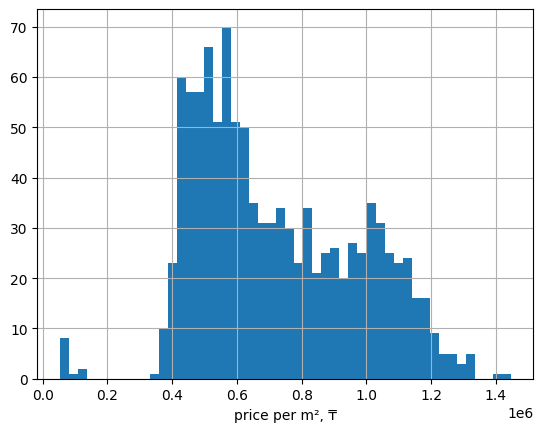

In [49]:
import matplotlib.pyplot as plt
df["price_per_m2"].hist(bins=50)
plt.xlabel("price per m², ₸")
plt.show()

In [50]:
def fences(values, groups):
    q1 = values.groupby(groups).transform("quantile", 0.25)
    q3 = values.groupby(groups).transform("quantile", 0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = fences(df["price_per_m2"], df["district"])
outliers_grouped = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)
print(outliers_grouped.sum())
print(df.loc[outliers_grouped, ["district", "price_per_m2"]].sort_values("price_per_m2"))

12
      district   price_per_m2
165    Turksib   52893.258427
939     Auezov   55028.441411
151    Turksib   55678.807947
986    Zhetysu   57609.147609
755     Alatau   57716.814159
505    Zhetysu   57724.550898
204    Zhetysu   62859.350850
1      Zhetysu   73437.500000
658  Bostandyk   86222.222222
311  Bostandyk  119405.405405
243      Medeu  121264.150943
830  Nauryzbay  680662.983425


In [51]:
low_outliers = df.loc[outliers_grouped & (df["price_per_m2"] < 200000)]
print(low_outliers[["district", "price_kzt", "area_m2", "price_per_m2"]])

      district  price_kzt  area_m2   price_per_m2
1      Zhetysu   54050000    736.0   73437.500000
151    Turksib   33630000    604.0   55678.807947
165    Turksib   18830000    356.0   52893.258427
204    Zhetysu   40670000    647.0   62859.350850
243      Medeu   64270000    530.0  121264.150943
311  Bostandyk   66270000    555.0  119405.405405
505    Zhetysu   38560000    668.0   57724.550898
658  Bostandyk   42680000    495.0   86222.222222
755     Alatau   32610000    565.0   57716.814159
939     Auezov   48370000    879.0   55028.441411
986    Zhetysu   27710000    481.0   57609.147609


In [52]:
ids_to_check = df.loc[outliers_grouped & (df["price_per_m2"] < 200000), "listing_id"]
print(raw.loc[raw["listing_id"].isin(ids_to_check), ["listing_id", "area_m2"]])

     listing_id area_m2
52    ALM-10264   495.0
191   ALM-10069   481.0
333   ALM-10072   530.0
627   ALM-10405   356.0
773   ALM-10440   879.0
834   ALM-10921   668.0
1000  ALM-10910   736.0
1007  ALM-10909   565.0
1073  ALM-10058   555.0
1101  ALM-10276   604.0
1193  ALM-11122   647.0


In [53]:
bad_ids = ids_to_check  # 11 listing_id из прошлого шага

mask = df["listing_id"].isin(bad_ids)
df.loc[mask, "area_m2"] = df.loc[mask, "area_m2"] / 10
df.loc[mask, "price_per_m2"] = df.loc[mask, "price_kzt"] / df.loc[mask, "area_m2"]

print(df.loc[mask, ["listing_id", "area_m2", "price_per_m2"]])

    listing_id  area_m2  price_per_m2
1    ALM-10910     73.6  7.343750e+05
151  ALM-10276     60.4  5.567881e+05
165  ALM-10405     35.6  5.289326e+05
204  ALM-11122     64.7  6.285935e+05
243  ALM-10072     53.0  1.212642e+06
311  ALM-10058     55.5  1.194054e+06
505  ALM-10921     66.8  5.772455e+05
658  ALM-10264     49.5  8.622222e+05
755  ALM-10909     56.5  5.771681e+05
939  ALM-10440     87.9  5.502844e+05
986  ALM-10069     48.1  5.760915e+05


In [54]:
low, high = fences(df["price_per_m2"], df["district"])
outliers_grouped = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)
print(outliers_grouped.sum())

1


In [55]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print(df.shape)

(1068, 13)


## Step 4 — Report

Sentinels replaced with NaN:
- floor == -1: 11
- year_built == 0: 23
- ceiling_height_m == 0: 23

Impossible values: floor > total_floors — 12 rows found, dropped (couldn't tell which of the two columns was wrong, and it's ~1% of the data).

Outliers (price_per_m2, IQR):
- Global IQR: 0 flagged (fences went negative — too wide to catch anything, districts have very different price levels)
- Grouped by district IQR: 12 flagged
  - 11 were a data entry bug: area_m2 was off by a factor of 10 (e.g. "736.0" instead of "73.6"), confirmed against the raw unparsed values. Fixed by dividing area_m2 by 10 and recomputing price_per_m2.
  - 1 (Nauryzbay, price_per_m2 ≈ 680,663) is a genuine expensive listing in a cheaper district, not an error — kept as is.

Saved data/almaty_apartments_clean.csv, shape after Step 4: (1068, 13)

In [56]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=3194)
train, test = train.copy(), test.copy()
print(train.shape, test.shape)
print(train.isna().sum())

(854, 13) (214, 13)
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                10
total_floors          0
year_built           60
building_type         0
ceiling_height_m    116
price_kzt             0
price_per_m2          0
area_before_fix       0
dtype: int64


In [57]:
for col in ["floor", "year_built", "ceiling_height_m"]:
    print(col)
    print(train.groupby("building_type")[col].apply(lambda x: x.isna().mean().round(3)))
    print()

floor
building_type
brick       0.010
monolith    0.013
panel       0.012
Name: floor, dtype: float64

year_built
building_type
brick       0.082
monolith    0.063
panel       0.069
Name: year_built, dtype: float64

ceiling_height_m
building_type
brick       0.164
monolith    0.033
panel       0.207
Name: ceiling_height_m, dtype: float64



In [58]:
print(len(train), len(train.dropna()))

854 675


In [59]:
from sklearn.metrics import mean_absolute_error

known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=3194).index
rest = train.drop(index=hidden)
answers = train.loc[hidden, "ceiling_height_m"]
print(len(hidden), "values hidden")

global_pred = rest["ceiling_height_m"].median()
mae_global = mean_absolute_error(answers, [global_pred] * len(answers))

group_med = rest.groupby("building_type")["ceiling_height_m"].median()
group_pred = train.loc[hidden, "building_type"].map(group_med)
mae_group = mean_absolute_error(answers, group_pred)

print("global median MAE:", mae_global)
print("group median MAE:", mae_group)

111 values hidden
global median MAE: 0.15153153153153154
group median MAE: 0.0847747747747748


In [60]:
ceiling_med_by_type = train.groupby("building_type")["ceiling_height_m"].median()
year_med = train["year_built"].median()
floor_med = train["floor"].median()

for frame in [train, test]:
    frame["ceiling_height_m"] = frame["ceiling_height_m"].fillna(frame["building_type"].map(ceiling_med_by_type))
    frame["year_built"] = frame["year_built"].fillna(year_med)
    frame["floor"] = frame["floor"].fillna(floor_med)

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]
print(train[NUMERIC].isna().sum())
print(test[NUMERIC].isna().sum())

rooms               0
area_m2             0
floor               0
total_floors        0
year_built          0
ceiling_height_m    0
dtype: int64
rooms               0
area_m2             0
floor               0
total_floors        0
year_built          0
ceiling_height_m    0
dtype: int64


## Step 5 — Report

Missing values on train (before filling):
- floor: 10
- year_built: 60
- ceiling_height_m: 116

Missing rate by building_type:
- floor: brick 1.0%, monolith 1.3%, panel 1.2% -> uniform -> MCAR
- year_built: brick 8.2%, monolith 6.3%, panel 6.9% -> mild variation, not strongly tied to building_type -> MCAR
- ceiling_height_m: brick 16.4%, monolith 3.3%, panel 20.7% -> monolith has 5-6x fewer missing values -> MAR, depends on building_type

dropna() would remove 179 of 854 training rows (21%) -- too costly given the MAR pattern above.

Masking experiment on ceiling_height_m (111 values hidden, predicted from the remaining 743 training rows):
- Global median MAE: 0.1515
- Group median (by building_type) MAE: 0.0848 -- wins, roughly half the error

Fill strategy (fit on train only, applied to train and test):
- ceiling_height_m: median per building_type -- MAR, and the masking test confirms group median is more accurate
- year_built: global median -- MCAR, missing rate doesn't vary meaningfully by building_type
- floor: global median -- MCAR, missing rate nearly identical across building_type

NaN count after filling: train 0, test 0 (all NUMERIC columns).

In [61]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

for name, scaler in [("Standard", StandardScaler()), ("MinMax", MinMaxScaler()), ("Robust", RobustScaler())]:
    scaled = scaler.fit_transform(train[["area_before_fix"]])
    print(name, "min:", scaled.min().round(2), "max:", scaled.max().round(2), "median:", pd.Series(scaled.ravel()).median().round(2))

Standard min: -0.7 max: 12.66 median: -0.18
MinMax min: 0.0 max: 1.0 median: 0.04
Robust min: -0.99 max: 24.38 median: -0.0


## Step 6a — Scaler sensitivity to outliers

Fit on area_before_fix (uncorrected area, still containing the /10 parsing errors):

| Scaler | min | max | median |
|---|---|---|---|
| Standard | -0.70 | 12.66 | -0.18 |
| MinMax | 0.00 | 1.00 | 0.04 |
| Robust | -0.99 | 24.38 | 0.00 |

MinMax is the most damaged: with the outlier stretching the max, half of all normal-sized apartments get squeezed into the first 4% of the [0,1] range, losing almost all meaningful variation between them. Standard is similarly skewed because the outlier inflates the mean and std used for scaling. Robust keeps the bulk of normal apartments well spread around a median of 0 (it scales by IQR, not min/max), even though the outlier itself still sits far away — it just doesn't distort everyone else's values.

In [62]:
scaler_train_only = StandardScaler().fit(train[["area_m2"]])
test_scaled_correct = scaler_train_only.transform(test[["area_m2"]])

combined = pd.concat([train[["area_m2"]], test[["area_m2"]]])
scaler_leaked = StandardScaler().fit(combined)
test_scaled_leaked = scaler_leaked.transform(test[["area_m2"]])

print("mean, fit on train only:", test_scaled_correct.mean())
print("mean, fit on train+test:", test_scaled_leaked.mean())

mean, fit on train only: -0.07192985274758137
mean, fit on train+test: -0.05838504612970227


## Step 6b — Why not fit on train + test together

Fitting a scaler (or imputer) on train + test combined means its learned numbers - mean, std, min, max, median -- are computed using values from the test set. When you then transform train with those numbers, information about the test set has leaked into training: the model indirectly "knows" something about data it's supposed to be evaluated on later.

Fit on train only, the scaled test mean is -0.0719. Fit on train+test combined, it shifts to -0.0584 - the test set is no longer centered around what the model actually learned from train, because the scaler's mean/std now include test values it shouldn't have seen.

This makes the test score optimistic and unreliable - it no longer measures how the model performs on truly unseen data, which defeats the point of having a test set. The rule from Step 5a applies here too: fit every scaler and imputer on train only, then use those same fitted parameters to transform both train and test.

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CATEGORICAL = ["district", "building_type"]
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])
X_test = pre.transform(test[NUMERIC + CATEGORICAL])

model = LinearRegression().fit(X_train, train["price_kzt"])
print(X_train.shape, X_test.shape)
print("NaN:", np.isnan(X_train).sum(), np.isnan(X_test).sum())
print("test R2:", model.score(X_test, test["price_kzt"]))

(854, 17) (214, 17)
NaN: 0 0
test R2: 0.9160208105037457


## Step 6c — Final matrix

X_train shape: (854, 17)
X_test shape: (214, 17)
NaN count: train 0, test 0

Test R2: 0.9160

This is above the reference solution's ~0.91, confirming the cleaning in Steps 3-5 didn't leave any major defects uncorrected - a single missed defect would have pulled this down to about 0.83.

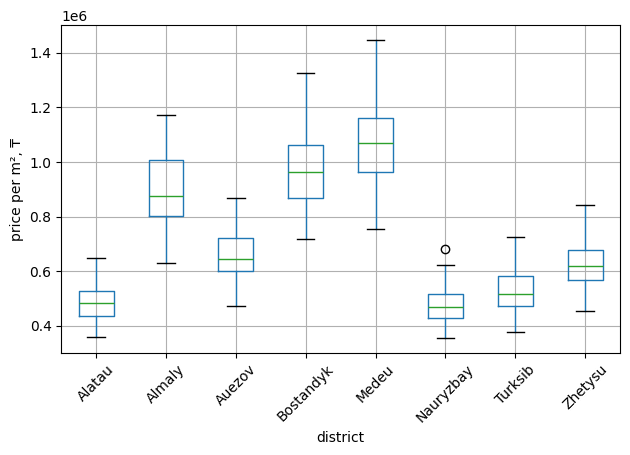

In [64]:
import matplotlib.pyplot as plt

df.boxplot(column="price_per_m2", by="district", rot=45)
plt.ylabel("price per m², ₸")
plt.suptitle("")
plt.title("")
plt.tight_layout()
plt.show()

In [65]:
print(df.groupby("district")["price_per_m2"].median().sort_values())

district
Nauryzbay    4.706402e+05
Alatau       4.843034e+05
Turksib      5.156838e+05
Zhetysu      6.211850e+05
Auezov       6.445693e+05
Almaly       8.761084e+05
Bostandyk    9.641956e+05
Medeu        1.070522e+06
Name: price_per_m2, dtype: float64


### Plot 1 — price_per_m2 by district

[boxplot]

Median price per m² ranges from 470,640 ₸ in Nauryzbay to 1,070,522 ₸ in Medeu -- Medeu is 2.3x more expensive per square meter than the cheapest district.

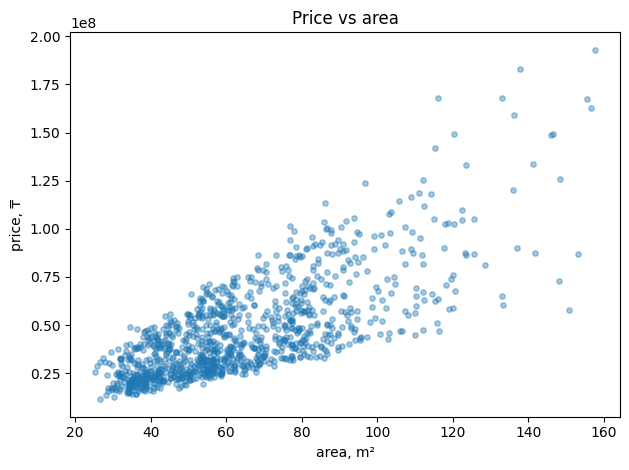

            area_m2  price_kzt
area_m2    1.000000   0.747053
price_kzt  0.747053   1.000000


In [66]:
plt.scatter(df["area_m2"], df["price_kzt"], alpha=0.4, s=15)
plt.xlabel("area, m²")
plt.ylabel("price, ₸")
plt.title("Price vs area")
plt.tight_layout()
plt.show()

print(df[["area_m2", "price_kzt"]].corr())

### Plot 2 — Price vs area

[scatter plot]

Price and area have a strong positive correlation of 0.75, and the spread of prices widens as area increases - e.g. among ~150 m² listings, price ranges from roughly 60M to 190M ₸, far wider than the spread among 30-40 m² listings.

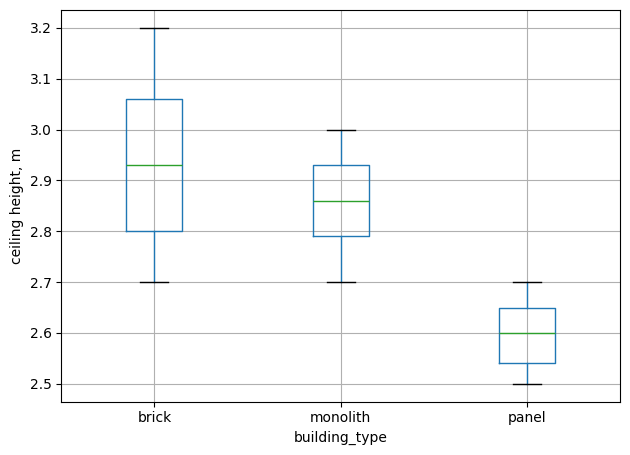

building_type
brick       2.93
monolith    2.86
panel       2.60
Name: ceiling_height_m, dtype: float64


In [67]:
df.boxplot(column="ceiling_height_m", by="building_type")
plt.ylabel("ceiling height, m")
plt.suptitle("")
plt.title("")
plt.tight_layout()
plt.show()

print(df.groupby("building_type")["ceiling_height_m"].median())

### Plot 3 — Ceiling height by building_type

[boxplot]

Panel buildings have the lowest median ceiling height at 2.60 m, 0.33 m less than brick's 2.93 m - a real, physically meaningful gap consistent with Soviet-era panel construction standards.

## Step 7 — Final cleaning log

| Step | Operation | Rows before | Rows after | Cells changed |
|---|---|---|---|---|
| 3a | Exact duplicates removed | 1153 | 1121 | - |
| 3a | Reposts resolved (kept latest listed_date) | 1121 | 1080 | - |
| 3b | District names standardized to 8 canonical values | 1080 | 1080 | 278 |
| 3c | rooms, area_m2, price_kzt parsed from text to numeric | 1080 | 1080 | 3240 (3 columns x 1080 rows) |
| 4.1 | Sentinels replaced with NaN (floor=-1, year_built=0, ceiling_height_m=0) | 1080 | 1080 | 57 (11+23+23) |
| 4.2 | Impossible values (floor > total_floors) dropped | 1080 | 1068 | - |
| 4.3 | Outliers (price_per_m2, IQR by district): 11 area_m2 /10 errors fixed, 1 genuine value kept | 1068 | 1068 | 11 |
| 5d | Missing values filled (ceiling_height_m by building_type median, year_built and floor by global median) -- train/test only, not in df | 1068 | 1068 | - |

data/almaty_apartments_clean.csv confirmed saved after Step 4 (before missing-value filling, NaNs still marked as required).

In [68]:
!git log --oneline

b826c4f (HEAD -> main, origin/main) Steps 6-7: scaling, encoding, final model check, EDA, cleaning log
40a64b3 Step 5: missing data — MCAR/MAR diagnosis, masking experiment, fill train/test
7dfb16a Steps 2-4: sampling, cleaning, sentinels, impossible values; outliers analysis in progress
1502a23 Initial commit
